# 02 | Retirement income, stress test, and estate review

The annual model is deterministic and **does not estimate a probability of success**. It shows whether the stated assumptions support the spending target and how a large loss at retirement changes the path. All spending and Social Security inputs are in 2026 dollars and inflate 2.5% yearly. The portfolio return is a nominal, constant 5% base case; contributions grow 2% until retirement. Portfolio withdrawals occur before each year's return. The 18% withdrawal tax reserve is a planning proxy, not a tax calculation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
import pandas as pd
import matplotlib.pyplot as plt
from financial_plan import Assumptions, project, summary

a = Assumptions()
base = pd.DataFrame(project(a))
stress = pd.DataFrame(project(a, shock_year=2036, shock_return=-0.20))
low_return = pd.DataFrame(project(Assumptions(nominal_return=0.04)))
combined = pd.DataFrame(project(Assumptions(nominal_return=0.04), shock_year=2036, shock_return=-0.20))
cases = pd.DataFrame({name: summary(frame.to_dict('records')) for name, frame in
                      [('Base: 5% nominal', base), ('2036 loss: -20%', stress), ('4% nominal', low_return), ('Combined downside', combined)]}).T
display(cases.style.format({'retirement_portfolio':'${:,.0f}', 'first_year_withdrawal':'${:,.0f}',
                            'first_year_rate':'{:.1%}', 'age_95_portfolio':'${:,.0f}'}))

,retirement_year,retirement_portfolio,first_year_withdrawal,first_year_rate,age_95_portfolio,first_shortfall_year
Base: 5% nominal,2036.000000,"$3,901,572","$226,356",5.8%,"$5,696,259",nan
2036 loss: -20%,2036.000000,"$3,901,572","$226,356",5.8%,"$1,725,241",nan
4% nominal,2036.000000,"$3,587,514","$226,356",6.3%,"$2,090,854",nan
Combined downside,2036.000000,"$3,587,514","$226,356",6.3%,$0,2064.000000


## Retirement paycheck

The couple retires in 2036. Elena's modeled Social Security begins at age 67 in 2038; Marco's begins at 67 in 2040. The two bridge years have the highest starting withdrawal pressure. The model does not optimize claiming ages or calculate taxation of Social Security, Medicare premiums, ACA coverage, capital gains, RMDs, or individual account withdrawal order.

,year,age_a,age_b,opening,spending,social_security,portfolio_withdrawal,withdrawal_rate,ending
9,2035,64,62,"$3,641,801",$0,$0,$0,0.0%,"$3,901,572"
10,2036,65,63,"$3,901,572","$185,612",$0,"$226,356",5.8%,"$3,858,977"
11,2037,66,64,"$3,858,977","$190,253",$0,"$232,015",6.0%,"$3,808,309"
12,2038,67,65,"$3,808,309","$195,009","$61,865","$162,371",4.3%,"$3,828,235"
13,2039,68,66,"$3,828,235","$199,884","$63,412","$166,430",4.3%,"$3,844,896"
14,2040,69,67,"$3,844,896","$204,881","$110,212","$115,450",3.0%,"$3,915,918"
15,2041,70,68,"$3,915,918","$210,003","$112,967","$118,337",3.0%,"$3,987,460"
16,2042,71,69,"$3,987,460","$215,253","$115,791","$121,295",3.0%,"$4,059,474"


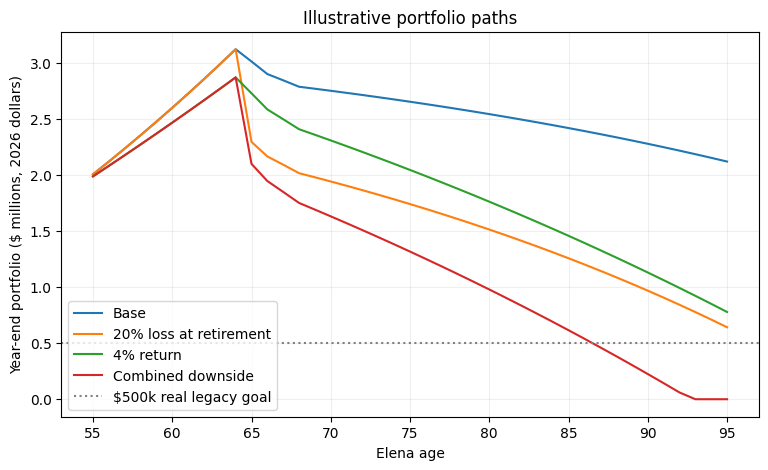

In [2]:
display(base.loc[base.year.between(2035, 2042),
                 ['year','age_a','age_b','opening','spending','social_security','portfolio_withdrawal','withdrawal_rate','ending']]
        .style.format({'opening':'${:,.0f}','spending':'${:,.0f}',
                       'social_security':'${:,.0f}','portfolio_withdrawal':'${:,.0f}',
                       'withdrawal_rate':'{:.1%}','ending':'${:,.0f}'}))
fig, ax = plt.subplots(figsize=(9, 5))
for label, frame in [('Base',base), ('20% loss at retirement',stress), ('4% return',low_return), ('Combined downside',combined)]:
    ax.plot(frame.age_a, frame.ending / 1e6 / (1+a.inflation)**(frame.year-a.start_year), label=label)
ax.axhline(.5, color='gray', linestyle=':', label='$500k real legacy goal')
ax.set(xlabel='Elena age', ylabel='Year-end portfolio ($ millions, 2026 dollars)', title='Illustrative portfolio paths')
ax.legend(); ax.grid(alpha=.2); plt.show()

## Withdrawal guardrail and adviser judgment

Compare the first retirement withdrawal with the opening retirement portfolio and the [Morningstar 2025 base-case 3.9% starting rate](https://www.morningstar.com/content/cs-assets/v3/assets/blt9415ea4cc4157833/bltb73b87c5d0c70ead/692f43f57737a31596684522/working_file_11.19_FINAL_REVISE.pdf), which assumes a 30-year horizon and 90% probability of funds remaining under its own capital-market assumptions. This case has a two-year Social Security bridge and a roughly 30-year horizon, so 3.9% is only a reference point. An adviser should review an annual guardrail: if the current withdrawal rate rises above 5%, pause discretionary increases and revisit the plan; below 4%, review whether spending or gifting can rise. These thresholds are illustrative policy choices, not proven safe rates.

In [3]:
retirement = base[base.retired].iloc[0]
print(f'Opening retirement portfolio: ${retirement.opening:,.0f}')
print(f'First-year gross portfolio withdrawal: ${retirement.portfolio_withdrawal:,.0f}')
print(f'First-year withdrawal rate: {retirement.withdrawal_rate:.2%}')
print(f'Base age-95 portfolio in 2026 dollars: ${base.iloc[-1].ending/(1+a.inflation)**(base.iloc[-1].year-a.start_year):,.0f}')
print(f'Loss scenario age-95 portfolio in 2026 dollars: ${stress.iloc[-1].ending/(1+a.inflation)**(stress.iloc[-1].year-a.start_year):,.0f}')

Opening retirement portfolio: $3,901,572
First-year gross portfolio withdrawal: $226,356
First-year withdrawal rate: 5.80%
Base age-95 portfolio in 2026 dollars: $2,121,461
Loss scenario age-95 portfolio in 2026 dollars: $642,533


## Estate, protection, and implementation checklist

1. **Title and beneficiaries:** reconcile the will or revocable trust with retirement-account and life-insurance beneficiary designations. Check contingent beneficiaries and whether assets pass outside probate.
2. **Incapacity:** have a qualified attorney prepare or review durable financial and health-care powers of attorney, advance directives, and any trust documents under the relevant state law. Name successors.
3. **Survivor and insurance risk:** review term-life coverage before retirement, disability coverage while working, long-term-care funding choices, and the cash needs of the surviving spouse. A single-survivor tax and Social Security model remains to be built from real client data.
4. **Estate tax:** the 2026 federal basic exclusion is $15 million per person. The current illustrative net worth is well below that level, so execution, beneficiary coordination, and state-specific law are more immediate than federal estate tax minimization. Future law and appreciation require review.
5. **Tax coordination:** review Roth conversions during lower-income years, investment location, RMD timing, charitable intent, and capital-gain realization with a tax professional. The present notebook does not optimize these decisions.

**Sources:** [IRS estate exclusion](https://www.irs.gov/instructions/i706), [CFPB durable financial power of attorney](https://www.consumerfinance.gov/ask-cfpb/what-is-a-power-of-attorney-poa-en-1149/), [IRS RMD FAQ](https://www.irs.gov/retirement-plans/retirement-plan-and-ira-required-minimum-distributions-faqs).